## Original separate data-loading cell (kept for reference)

In [1]:
from pathlib import Path
import pandas as pd

# Load the pathogenic BRCA1 variants (use the second path when running from data/).
csv_path = Path("data/pathogenic_BRCA1_filtered.csv")
if not csv_path.exists():
    csv_path = Path("pathogenic_BRCA1_filtered.csv")

pathogenic_brca1 = pd.read_csv(csv_path)
print("Shape:", pathogenic_brca1.shape)
print("Columns:", pathogenic_brca1.columns.tolist())

# Select the first unique variant and parse its VEP metadata.
first_variant = pathogenic_brca1.iloc[0]
extra_fields = {
    key: value
    for field in str(first_variant["Extra"]).split(";")
    if "=" in field
    for key, value in [field.split("=", 1)]
}
chromosome, position_range = str(first_variant["Location"]).split(":", 1)

# @markdown Specify the variant:
variant_chromosome = f"chr{chromosome.removeprefix('chr')}"
variant_position = int(position_range.split("-", 1)[0])
variant_reference_bases = extra_fields["REF_ALLELE"].upper()
variant_alternate_bases = str(first_variant["Allele"]).upper()

print("\nFirst variant formatted for AlphaGenome:")
print(f"variant_chromosome = {variant_chromosome!r}")
print(f"variant_position = {variant_position}")
print(f"variant_reference_bases = {variant_reference_bases!r}")
print(f"variant_alternate_bases = {variant_alternate_bases!r}")

Shape: (94, 14)
Columns: ['#Uploaded_variation', 'Location', 'Allele', 'Gene', 'Feature', 'Feature_type', 'Consequence', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'Extra']

First variant formatted for AlphaGenome:
variant_chromosome = 'chr17'
variant_position = 43045712
variant_reference_bases = 'T'
variant_alternate_bases = 'C'


## Scoring and visualizing a single variant#


In [1]:
# @title Install AlphaGenome

# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output
! pip install alphagenome
clear_output()

## All-in-one: load, score, filter RNA-seq, and plot



Shape: (94, 14)
Columns: ['#Uploaded_variation', 'Location', 'Allele', 'Gene', 'Feature', 'Feature_type', 'Consequence', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'Extra']

First variant formatted for AlphaGenome:
variant_chromosome = 'chr17'
variant_position = 43045712
variant_reference_bases = 'T'
variant_alternate_bases = 'C'

RNA-seq scores only (66,409 tracks):


,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,transcription_factor,histone_mark,gtex_tissue,raw_score,quantile_score
3791,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000047 polyA plus RNA-seq,.,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,encode,paired,False,NaN,NaN,,-0.003446,-0.938810
3792,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000062 total RNA-seq,.,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,encode,paired,False,NaN,NaN,,-0.008003,-0.996910
3793,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 polyA plus RNA-seq,.,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,NaN,NaN,,-0.001385,-0.754166
3794,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 total RNA-seq,.,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,encode,single,False,NaN,NaN,,-0.000188,-0.371041
3795,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000115 total RNA-seq,.,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,encode,single,False,NaN,NaN,,-0.005588,-0.989218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72032,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,PolyadenylationScorer(),UBERON:0018115 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018115,left renal pelvis,tissue,embryonic,encode,single,False,NaN,NaN,,0.021072,0.989080
72033,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,PolyadenylationScorer(),UBERON:0018116 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,embryonic,encode,single,False,NaN,NaN,,0.023977,0.990766
72034,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,PolyadenylationScorer(),UBERON:0018117 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,embryonic,encode,single,False,NaN,NaN,,0.015327,0.983691
72035,ENSG00000012048,BRCA1,protein_coding,-,None,None,RNA_SEQ,PolyadenylationScorer(),UBERON:0018118 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,embryonic,encode,single,False,NaN,NaN,,0.037717,0.994036



Top five RNA-seq ontology terms by absolute raw-score change:


,ontology_curie,biosample_name,track_name,raw_score,quantile_score
0,UBERON:1000010,mole,UBERON:1000010 polyA plus RNA-seq,59.865295,0.999477
1,EFO:0002785,GM12891,EFO:0002785 polyA plus RNA-seq,53.911293,0.999241
2,CL:0000900,"naive thymus-derived CD8-positive, alpha-beta T cell",CL:0000900 polyA plus RNA-seq,49.149719,0.999266
3,EFO:0002786,GM12892,EFO:0002786 polyA plus RNA-seq,48.716068,0.999241
4,CL:0000792,"CD4-positive, CD25-positive, alpha-beta regulatory T cell",CL:0000792 polyA plus RNA-seq,40.706112,0.999215


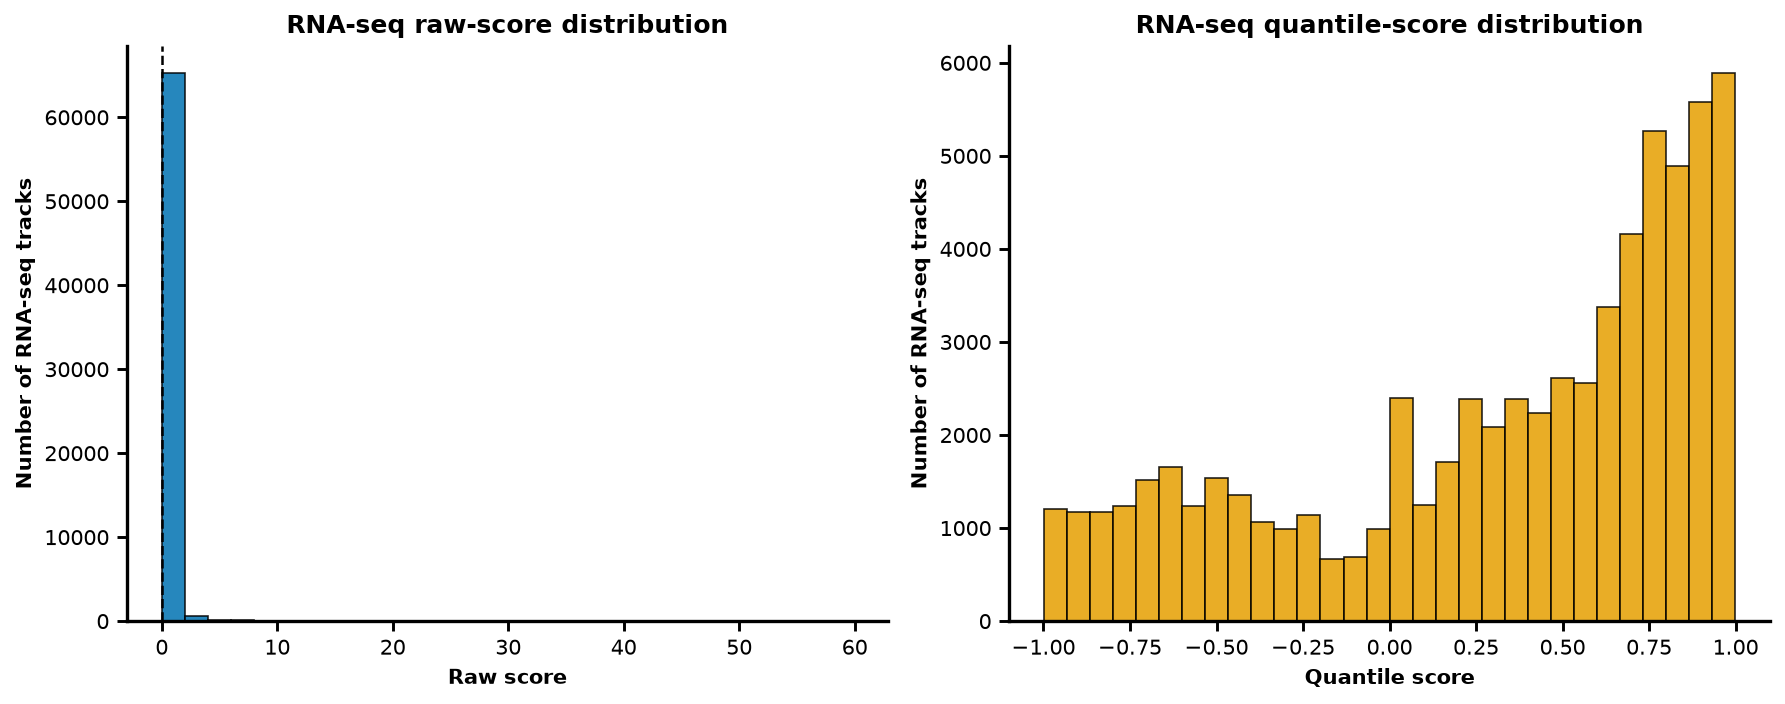

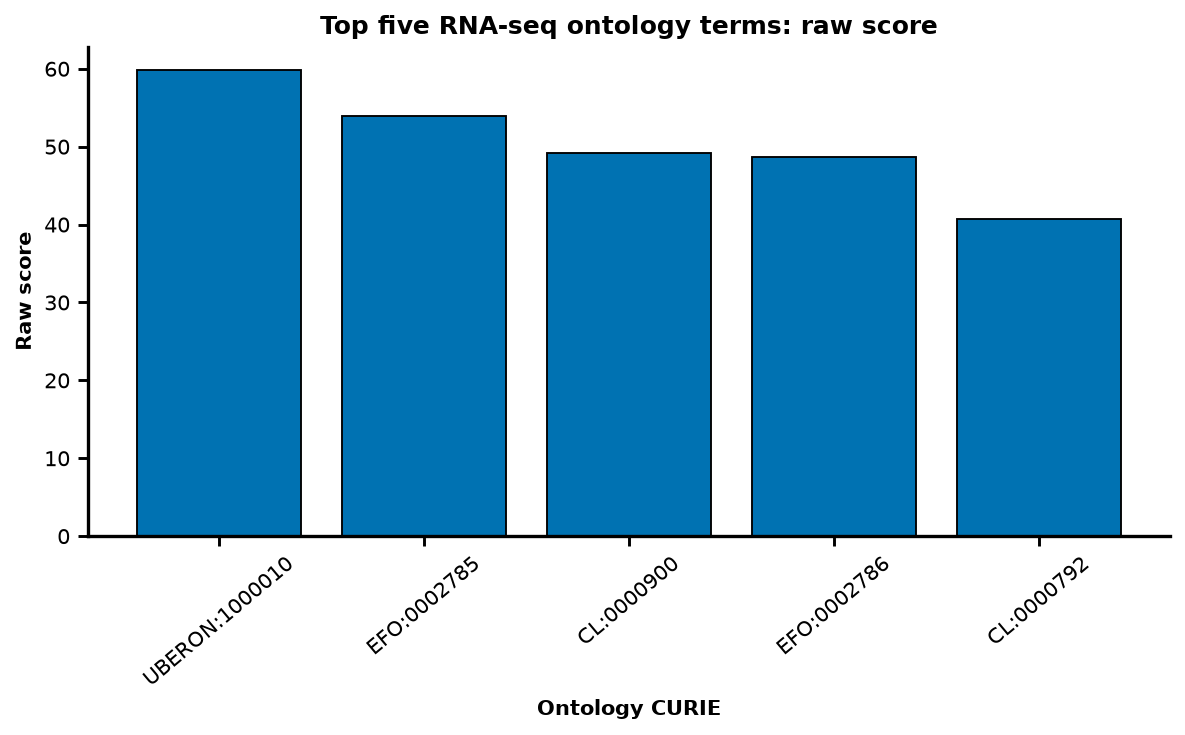

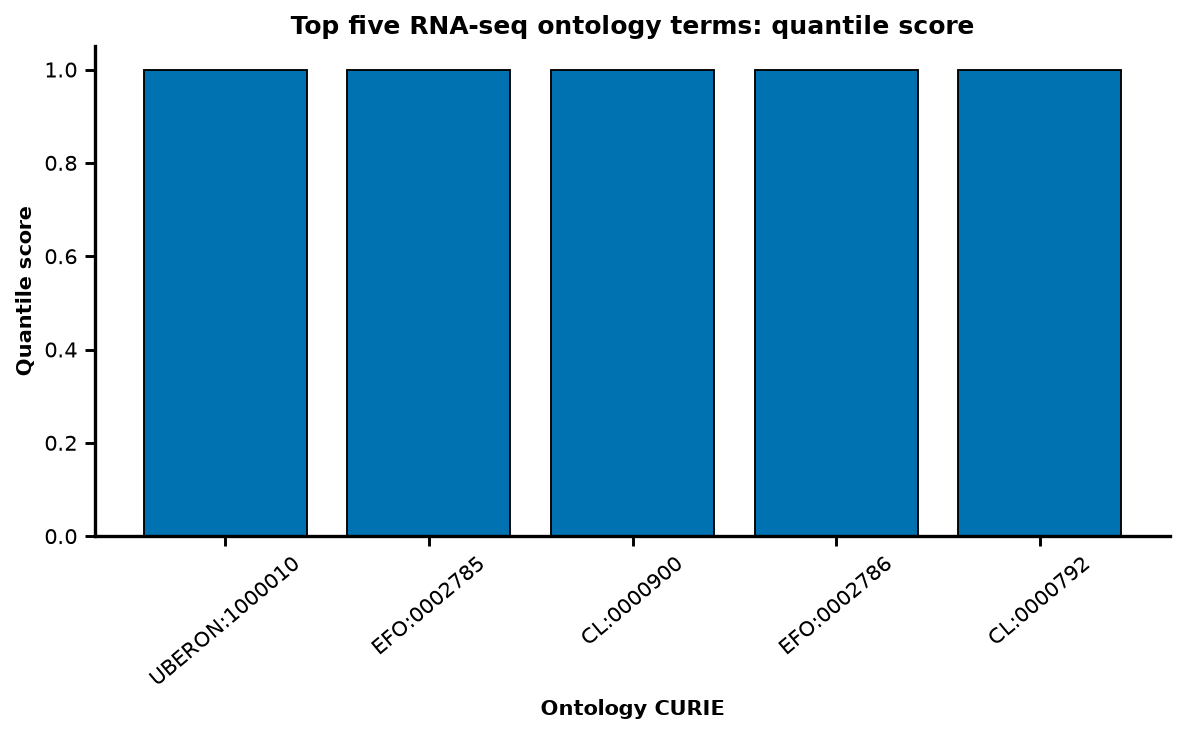

In [7]:
from pathlib import Path
from getpass import getpass
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from alphagenome import colab_utils
from alphagenome.data import gene_annotation, genome, transcript, track_data
from alphagenome.models import dna_client, variant_scorers
from alphagenome.visualization import plot_components

pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# 1. Load only the prepared pathogenic BRCA1 CSV and select its first row.
csv_path = Path("data/pathogenic_BRCA1_filtered.csv")
if not csv_path.exists():
    csv_path = Path("pathogenic_BRCA1_filtered.csv")

pathogenic_brca1 = pd.read_csv(csv_path)
print("Shape:", pathogenic_brca1.shape)
print("Columns:", pathogenic_brca1.columns.tolist())

first_variant = pathogenic_brca1.iloc[0]
extra_fields = {
    key: value
    for field in str(first_variant["Extra"]).split(";")
    if "=" in field
    for key, value in [field.split("=", 1)]
}
chromosome, position_range = str(first_variant["Location"]).split(":", 1)

# @markdown Variant prepared from the first CSV row:
variant_chromosome = f"chr{chromosome.removeprefix('chr')}"
variant_position = int(position_range.split("-", 1)[0])
variant_reference_bases = extra_fields["REF_ALLELE"].upper()
variant_alternate_bases = str(first_variant["Allele"]).upper()

print("\nFirst variant formatted for AlphaGenome:")
print(f"variant_chromosome = {variant_chromosome!r}")
print(f"variant_position = {variant_position}")
print(f"variant_reference_bases = {variant_reference_bases!r}")
print(f"variant_alternate_bases = {variant_alternate_bases!r}")

# 2. Initialize AlphaGenome and score the selected variant.
ALPHA_GENOME_API_KEY = os.environ.get("ALPHAGENOME_API_KEY")
if not ALPHA_GENOME_API_KEY:
    try:
        from google.colab import userdata
        ALPHA_GENOME_API_KEY = userdata.get("ALPHAGENOME_API_KEY")
    except Exception:
        ALPHA_GENOME_API_KEY = None
if not ALPHA_GENOME_API_KEY:
    ALPHA_GENOME_API_KEY = getpass("Enter your AlphaGenome API key: ").strip()
if not ALPHA_GENOME_API_KEY:
    raise ValueError("An AlphaGenome API key is required to score the variant.")
os.environ["ALPHAGENOME_API_KEY"] = ALPHA_GENOME_API_KEY
dna_model = dna_client.create(ALPHA_GENOME_API_KEY)
organism = dna_client.Organism.HOMO_SAPIENS

variant = genome.Variant(
    chromosome=variant_chromosome,
    position=variant_position,
    reference_bases=variant_reference_bases,
    alternate_bases=variant_alternate_bases,
)
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS["SEQUENCE_LENGTH_1MB"]
interval = variant.reference_interval.resize(sequence_length)
variant_scores = dna_model.score_variant(
    interval=interval,
    variant=variant,
    variant_scorers=list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.values()),
)
df_scores = variant_scorers.tidy_scores(variant_scores)

download_predictions = False  # @param { type: "boolean" }
if download_predictions:
    score_output = f"{variant}_scores.csv"
    df_scores.to_csv(score_output, index=False)
    try:
        from google.colab import files
        files.download(score_output)
    except ImportError:
        print(f"Saved {score_output}")

# 3. Display RNA-seq scores only.
rna_output = (
    df_scores["output_type"]
    .astype(str)
    .str.upper()
    .str.replace("-", "_", regex=False)
)
rna_seq_scores = df_scores[rna_output.str.endswith("RNA_SEQ")].copy()
if rna_seq_scores.empty:
    raise ValueError("AlphaGenome returned no RNA-seq scores for this variant.")

for score_column in ["raw_score", "quantile_score"]:
    rna_seq_scores[score_column] = pd.to_numeric(
        rna_seq_scores[score_column], errors="coerce"
    )

rna_display_columns = [
    column for column in rna_seq_scores.columns
    if column not in ["variant_id", "scored_interval"]
]
print(f"\nRNA-seq scores only ({len(rna_seq_scores):,} tracks):")
display(rna_seq_scores[rna_display_columns])

# 4. Keep the strongest RNA-seq track per ontology and select the top five.
rankable_scores = rna_seq_scores.dropna(
    subset=["ontology_curie", "raw_score"]
).copy()
rankable_scores["absolute_raw_score"] = rankable_scores["raw_score"].abs()
strongest_track_index = (
    rankable_scores.groupby("ontology_curie")["absolute_raw_score"].idxmax()
)
top_five_ontologies = (
    rankable_scores.loc[strongest_track_index]
    .nlargest(5, "absolute_raw_score")
    .reset_index(drop=True)
)

top_columns = [
    column for column in [
        "ontology_curie", "biosample_name", "track_name",
        "raw_score", "quantile_score",
    ] if column in top_five_ontologies.columns
]
print("\nTop five RNA-seq ontology terms by absolute raw-score change:")
display(top_five_ontologies[top_columns])

# 5. Plot score distributions across all RNA-seq tracks.
plt.rcParams.update({
    "figure.dpi": 150, "axes.grid": False, "axes.linewidth": 1.6,
    "axes.titleweight": "bold", "axes.labelweight": "bold",
})

histogram_bins = max(10, min(30, int(len(rna_seq_scores) ** 0.5)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].hist(
    rna_seq_scores["raw_score"].dropna(), bins=histogram_bins,
    color="#0072B2", edgecolor="black", linewidth=0.8, alpha=0.85,
)
axes[0].axvline(0, color="black", linewidth=1.2, linestyle="--")
axes[0].set(
    title="RNA-seq raw-score distribution",
    xlabel="Raw score", ylabel="Number of RNA-seq tracks",
)

axes[1].hist(
    rna_seq_scores["quantile_score"].dropna(), bins=histogram_bins,
    color="#E69F00", edgecolor="black", linewidth=0.8, alpha=0.85,
)
axes[1].set(
    title="RNA-seq quantile-score distribution",
    xlabel="Quantile score", ylabel="Number of RNA-seq tracks",
)

for ax in axes:
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)
    ax.tick_params(axis="both", width=1.4, length=5)

plt.tight_layout()
plt.show()

# 6. Plot raw and quantile scores for the same five ontology terms.
def plot_ontology_scores(data, score_column, ylabel, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#D55E00" if value < 0 else "#0072B2" for value in data[score_column]]
    ax.bar(
        data["ontology_curie"].astype(str), data[score_column],
        color=colors, edgecolor="black", linewidth=0.9,
    )
    ax.axhline(0, color="black", linewidth=1.2)
    ax.set(xlabel="Ontology CURIE", ylabel=ylabel, title=title)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)
    ax.tick_params(axis="both", width=1.4, length=5)
    ax.tick_params(axis="x", rotation=40)
    plt.tight_layout()
    plt.show()

plot_ontology_scores(
    top_five_ontologies, "raw_score", "Raw score",
    "Top five RNA-seq ontology terms: raw score",
)
plot_ontology_scores(
    top_five_ontologies, "quantile_score", "Quantile score",
    "Top five RNA-seq ontology terms: quantile score",
)

# Objects retained for the downstream visualization cells.
HG38_GTF_FEATHER = (
    "https://storage.googleapis.com/alphagenome/reference/gencode/"
    "hg38/gencode.v46.annotation.gtf.gz.feather"
)
MM10_GTF_FEATHER = (
    "https://storage.googleapis.com/alphagenome/reference/gencode/"
    "mm10/gencode.vM23.annotation.gtf.gz.feather"
)
_prediction_cache = {}
_transcript_extractor_cache = {}

## Batch comparison: pathogenic and benign BRCA1 variants

Scores all prepared variants with the same RNA-seq scorer, retains BRCA1 scores for UBERON:1000010 (mole), then stratifies consequences and plots one absolute quantile score per variant. Checkpointing allows an interrupted API run to resume.

Pathogenic: 94; benign: 653; combined: 747
Prepared 747 unique AlphaGenome variants.


I0713 09:08:33.752044 1719522 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


  0%|          | 0/25 [00:00<?, ?it/s]

Checkpointed 25/747 pending variants.


  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

Checkpointed 725/747 pending variants.


  0%|          | 0/22 [00:00<?, ?it/s]

Checkpointed 747/747 pending variants.

Transcript-aware category counts:


n_variants
Pathogenic Coding (missense)              88
           Coding (non-missense)           6
           Non-coding                      0
Benign     Coding (missense)             133
           Coding (non-missense)          23
           Non-coding                    497

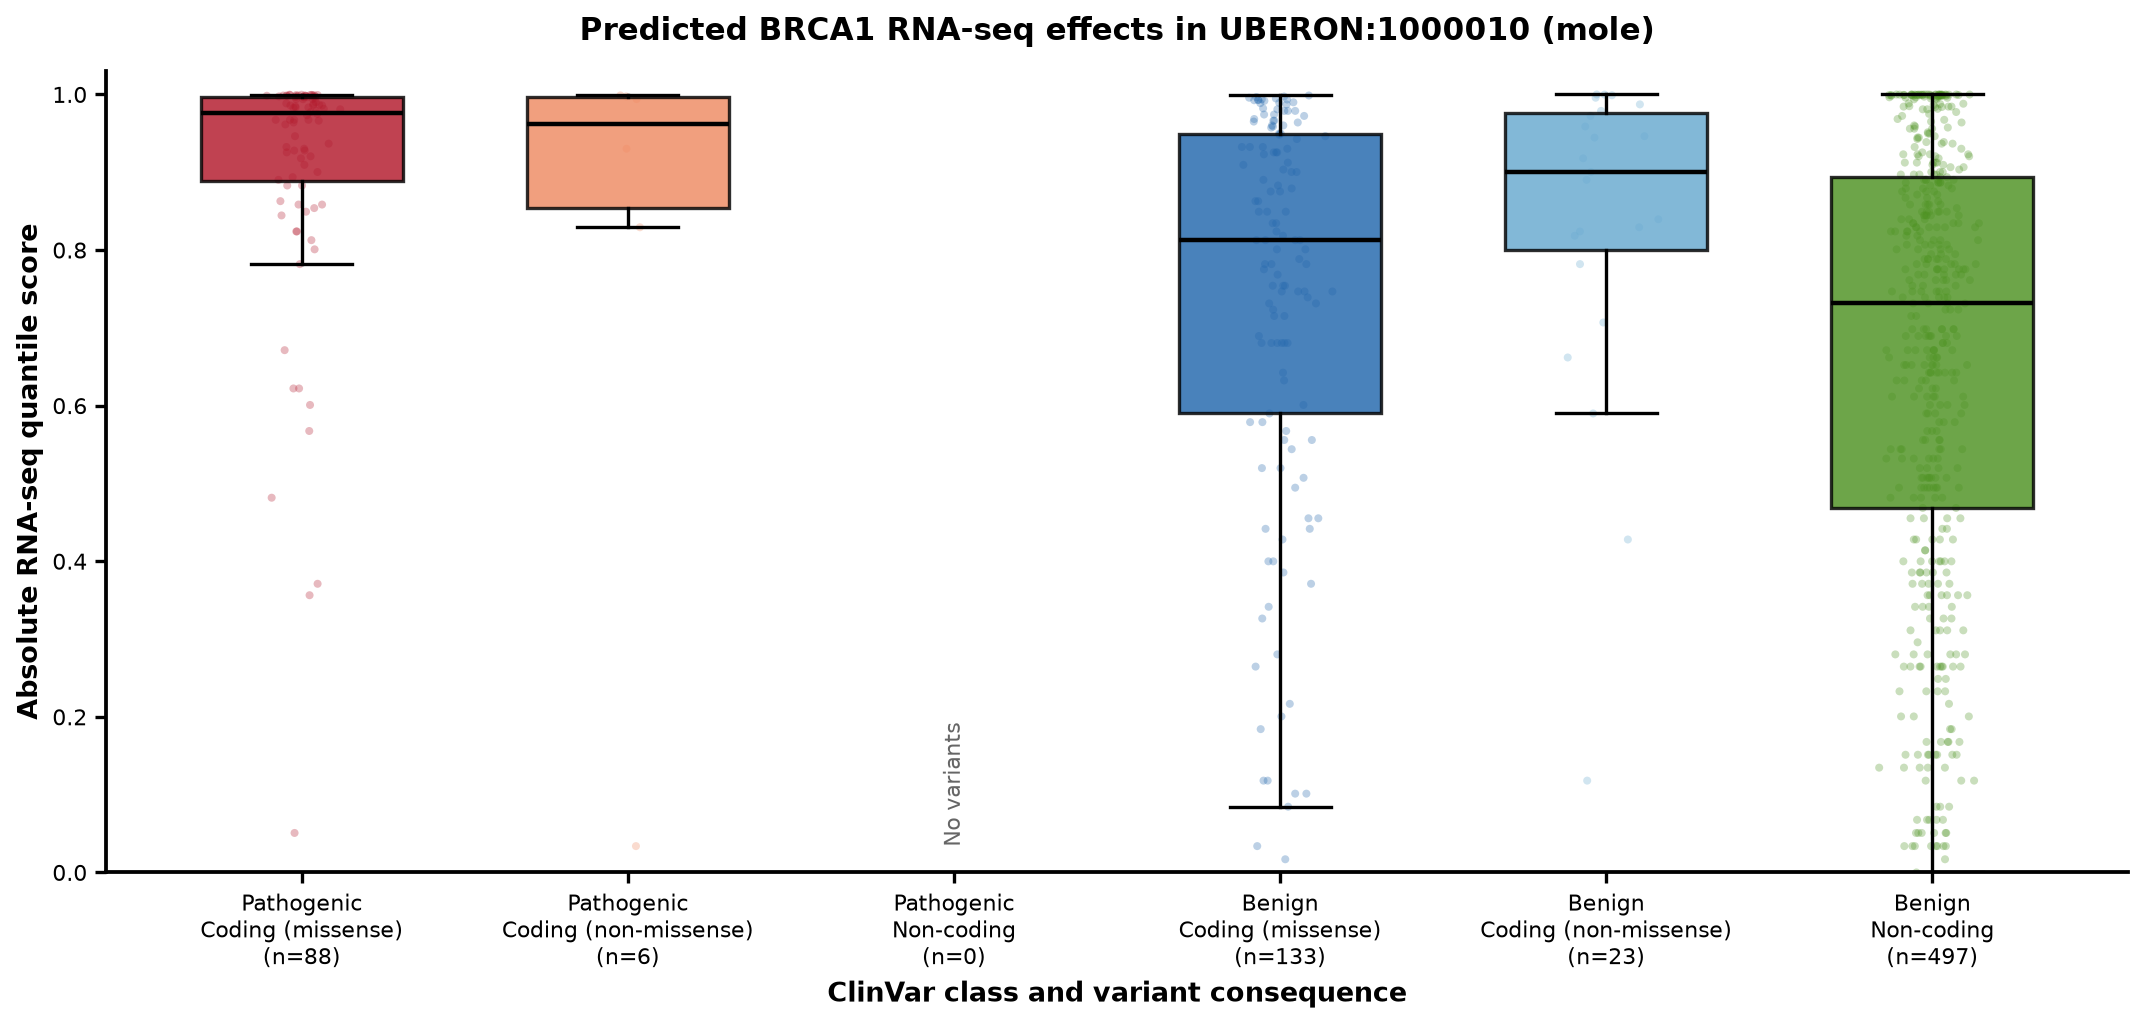

Checkpoint: data/alphagenome_BRCA1_UBERON_1000010_RNA_SEQ_scores.csv
Analysis table: data/alphagenome_BRCA1_UBERON_1000010_grouped_analysis.csv


In [8]:
# @title Full pathogenic-versus-benign BRCA1 RNA-seq analysis
from pathlib import Path
from getpass import getpass
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import mannwhitneyu
from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers

TARGET_GENE = "BRCA1"
TARGET_ONTOLOGY = "UBERON:1000010"  # Mole RNA-seq track.
SEQUENCE_LENGTH = "1MB"
BATCH_SIZE = 25
MAX_WORKERS = 5
FORCE_RESCORE = False

data_dir = Path("data")
if not (data_dir / "pathogenic_BRCA1_filtered.csv").exists():
    data_dir = Path(".")
checkpoint_path = data_dir / "alphagenome_BRCA1_UBERON_1000010_RNA_SEQ_scores.csv"
analysis_output_path = data_dir / "alphagenome_BRCA1_UBERON_1000010_grouped_analysis.csv"

# 1. Merge both cohorts before any scoring.
pathogenic = pd.read_csv(data_dir / "pathogenic_BRCA1_filtered.csv", low_memory=False)
benign = pd.read_csv(data_dir / "benign_BRCA1_filtered.csv", low_memory=False)
pathogenic["clinical_class"] = "Pathogenic"
benign["clinical_class"] = "Benign"
combined = pd.concat([pathogenic, benign], ignore_index=True, sort=False)
print(f"Pathogenic: {len(pathogenic):,}; benign: {len(benign):,}; combined: {len(combined):,}")

def extra_fields(value):
    return {
        key: item for field in str(value).split(";") if "=" in field
        for key, item in [field.split("=", 1)]
    }

def row_to_variant(row):
    chromosome, location = str(row["Location"]).split(":", 1)
    chromosome = f"chr{chromosome.removeprefix('chr')}"
    position = int(location.split("-", 1)[0])  # Both VEP and AlphaGenome are 1-based.
    reference = (
        str(row["REF_ALLELE"]) if pd.notna(row.get("REF_ALLELE"))
        else extra_fields(row.get("Extra", ""))["REF_ALLELE"]
    )
    reference = reference.replace("-", "").upper()
    alternate = str(row["Allele"]).replace("-", "").upper()
    allowed = set("ACGTN")
    if not set(reference).issubset(allowed) or not set(alternate).issubset(allowed):
        raise ValueError(f"Invalid allele for {row['#Uploaded_variation']}")
    if reference == alternate:
        raise ValueError(f"REF equals ALT for {row['#Uploaded_variation']}")
    return genome.Variant(
        chromosome=chromosome, position=position,
        reference_bases=reference, alternate_bases=alternate,
        name=str(row["#Uploaded_variation"]),
    )

variant_objects = [row_to_variant(row) for _, row in combined.iterrows()]
metadata = pd.DataFrame({
    "alpha_variant_id": [str(value) for value in variant_objects],
    "source_variant_id": combined["#Uploaded_variation"].astype(str),
    "clinical_class": combined["clinical_class"],
    "csv_consequence": combined["Consequence"],
})
if metadata["alpha_variant_id"].duplicated().any():
    raise ValueError("Duplicate genomic variants exist across the combined cohorts.")
variant_by_id = {str(value): value for value in variant_objects}
print(f"Prepared {len(metadata):,} unique AlphaGenome variants.")

# 2. Initialize AlphaGenome securely.
api_key = os.environ.get("ALPHAGENOME_API_KEY")
if not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get("ALPHAGENOME_API_KEY")
    except Exception:
        api_key = None
if not api_key:
    api_key = getpass("Enter your AlphaGenome API key: ").strip()
if not api_key:
    raise ValueError("An AlphaGenome API key is required.")
dna_model_batch = dna_client.create(api_key)
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[f"SEQUENCE_LENGTH_{SEQUENCE_LENGTH}"]
rna_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS["RNA_SEQ"]

# 3. Score all variants identically; batching only provides resilience.
if checkpoint_path.exists() and not FORCE_RESCORE:
    saved_scores = pd.read_csv(checkpoint_path, low_memory=False)
    completed_ids = set(saved_scores["variant_id"].astype(str))
    print(f"Resuming from {len(completed_ids):,} checkpointed variants.")
else:
    saved_scores = pd.DataFrame()
    completed_ids = set()
pending = metadata[~metadata["alpha_variant_id"].isin(completed_ids)].reset_index(drop=True)

for start in range(0, len(pending), BATCH_SIZE):
    batch_meta = pending.iloc[start:start + BATCH_SIZE]
    batch_variants = [variant_by_id[item] for item in batch_meta["alpha_variant_id"]]
    batch_intervals = [item.reference_interval.resize(sequence_length) for item in batch_variants]
    batch_results = dna_model_batch.score_variants(
        intervals=batch_intervals, variants=batch_variants,
        variant_scorers=[rna_scorer],
        organism=dna_client.Organism.HOMO_SAPIENS,
        progress_bar=True, max_workers=MAX_WORKERS,
    )

    # Filter AnnData before tidying so hundreds of irrelevant tracks are not materialized.
    filtered_results = []
    for result in batch_results:
        rna = result[0]
        track_mask = rna.var["ontology_curie"].astype(str).eq(TARGET_ONTOLOGY)
        gene_mask = rna.obs["gene_name"].astype(str).eq(TARGET_GENE)
        if not track_mask.any() or not gene_mask.any():
            raise ValueError(f"Missing {TARGET_GENE}/{TARGET_ONTOLOGY} RNA-seq score.")
        filtered_results.append([rna[gene_mask, track_mask].copy()])
    batch_scores = variant_scorers.tidy_scores(filtered_results)
    if batch_scores.empty:
        raise ValueError("A scoring batch produced no target scores.")
    saved_scores = pd.concat([saved_scores, batch_scores], ignore_index=True, sort=False)
    saved_scores.to_csv(checkpoint_path, index=False)
    print(f"Checkpointed {min(start + len(batch_meta), len(pending)):,}/{len(pending):,} pending variants.")

saved_scores["variant_id"] = saved_scores["variant_id"].astype(str)
for column in ["raw_score", "quantile_score"]:
    saved_scores[column] = pd.to_numeric(saved_scores[column], errors="coerce")

# One observation per variant: median across replicate target tracks, if any.
per_variant = (
    saved_scores.groupby("variant_id", as_index=False)
    .agg(
        signed_quantile_score=("quantile_score", "median"),
        raw_score=("raw_score", "median"),
        n_target_tracks=("quantile_score", "size"),
    )
)
per_variant["absolute_quantile_score"] = per_variant["signed_quantile_score"].abs()

# 4. Stratify only after scoring, using every transcript annotation when available.
coding_terms = {
    "coding_sequence_variant", "missense_variant", "synonymous_variant",
    "stop_gained", "stop_lost", "start_lost", "frameshift_variant",
    "inframe_insertion", "inframe_deletion", "protein_altering_variant",
}

def classify_consequences(values):
    terms = set()
    for value in values.dropna():
        terms.update(item.strip() for item in str(value).split(","))
    if "missense_variant" in terms:
        return "Coding (missense)"
    if terms & coding_terms:
        return "Coding (non-missense)"
    return "Non-coding"

def category_map(clinical_class, raw_filename):
    relevant = set(metadata.loc[metadata["clinical_class"] == clinical_class, "source_variant_id"])
    raw_path = data_dir / raw_filename
    if raw_path.exists():
        annotations = pd.read_csv(raw_path, sep="\t", low_memory=False)
        annotations = annotations[annotations["#Uploaded_variation"].astype(str).isin(relevant)]
    else:
        print(f"Warning: {raw_filename} missing; using the single CSV annotation.")
        annotations = combined[combined["clinical_class"] == clinical_class]
    return annotations.groupby("#Uploaded_variation")["Consequence"].apply(classify_consequences)

maps = {
    "Pathogenic": category_map("Pathogenic", "ClinVar_pathogenic_data.txt"),
    "Benign": category_map("Benign", "ClinVar_benign_data.txt"),
}
metadata["variant_category"] = pd.NA
for clinical_class, mapping in maps.items():
    mask = metadata["clinical_class"] == clinical_class
    metadata.loc[mask, "variant_category"] = metadata.loc[mask, "source_variant_id"].map(mapping)

analysis_df = metadata.merge(
    per_variant, left_on="alpha_variant_id", right_on="variant_id",
    how="left", validate="one_to_one",
)
analysis_df.to_csv(analysis_output_path, index=False)
missing = analysis_df["absolute_quantile_score"].isna().sum()
if missing:
    print(f"Warning: {missing:,} variants lack a target score.")

category_order = [
    ("Pathogenic", "Coding (missense)"),
    ("Pathogenic", "Coding (non-missense)"),
    ("Pathogenic", "Non-coding"),
    ("Benign", "Coding (missense)"),
    ("Benign", "Coding (non-missense)"),
    ("Benign", "Non-coding"),
]
counts = (
    analysis_df.groupby(["clinical_class", "variant_category"]).size()
    .reindex(pd.MultiIndex.from_tuples(category_order), fill_value=0)
)
print("\nTranscript-aware category counts:")
display(counts.rename("n_variants").to_frame())

# 5. Publication-style six-slot boxplot of effect magnitude.
plot_df = analysis_df.dropna(subset=["variant_category", "absolute_quantile_score"])
colors = ["#B2182B", "#EF8A62", "#BDBDBD", "#2166AC", "#67A9CF", "#4D9221"]
values_list, positions, used_colors, labels = [], [], [], []
for position, ((clinical_class, category), color) in enumerate(zip(category_order, colors), 1):
    values = plot_df.loc[
        (plot_df["clinical_class"] == clinical_class)
        & (plot_df["variant_category"] == category),
        "absolute_quantile_score",
    ].to_numpy()
    labels.append(f"{clinical_class}\n{category}\n(n={len(values):,})")
    if len(values):
        values_list.append(values); positions.append(position); used_colors.append(color)

fig, ax = plt.subplots(figsize=(13.5, 6.5), dpi=160)
boxes = ax.boxplot(
    values_list, positions=positions, widths=0.62, patch_artist=True, showfliers=False,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"color": "black", "linewidth": 1.5},
    capprops={"color": "black", "linewidth": 1.5},
    boxprops={"edgecolor": "black", "linewidth": 1.5},
)
for box, color in zip(boxes["boxes"], used_colors):
    box.set_facecolor(color); box.set_alpha(0.82)
rng = np.random.default_rng(42)
for position, values, color in zip(positions, values_list, used_colors):
    ax.scatter(
        position + rng.normal(0, 0.055, len(values)), values,
        s=13, alpha=0.30, color=color, edgecolors="none", rasterized=True,
    )
for position in sorted(set(range(1, 7)) - set(positions)):
    ax.text(position, 0.04, "No variants", rotation=90, ha="center", color="#666666")
ax.set_xticks(range(1, 7), labels)
ax.set(xlim=(0.4, 6.6), ylim=(0, 1.03))
ax.set_xlabel("ClinVar class and variant consequence", fontsize=12, fontweight="bold")
ax.set_ylabel("Absolute RNA-seq quantile score", fontsize=12, fontweight="bold")
ax.set_title(
    f"Predicted {TARGET_GENE} RNA-seq effects in {TARGET_ONTOLOGY} (mole)",
    fontsize=14, fontweight="bold", pad=14,
)
ax.grid(False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.7); ax.spines["bottom"].set_linewidth(1.7)
ax.tick_params(axis="both", width=1.5, length=5, labelsize=10)
plt.tight_layout(); plt.show()

# 6. Collapse consequences and compare pathogenic versus benign variants.
pathogenic_scores = plot_df.loc[
    plot_df["clinical_class"] == "Pathogenic", "absolute_quantile_score"
].to_numpy()
benign_scores = plot_df.loc[
    plot_df["clinical_class"] == "Benign", "absolute_quantile_score"
].to_numpy()
if not len(pathogenic_scores) or not len(benign_scores):
    raise ValueError("Both clinical classes need scores for the two-group test.")

# Independent groups: Mann-Whitney U is the Wilcoxon rank-sum test.
u_statistic, p_value = mannwhitneyu(
    pathogenic_scores, benign_scores, alternative="two-sided", method="auto"
)
rank_biserial = (
    2 * u_statistic / (len(pathogenic_scores) * len(benign_scores)) - 1
)
pathogenic_median = np.median(pathogenic_scores)
benign_median = np.median(benign_scores)

print("\nPathogenic versus benign comparison")
print(f"Pathogenic: n={len(pathogenic_scores):,}, median={pathogenic_median:.3f}")
print(f"Benign: n={len(benign_scores):,}, median={benign_median:.3f}")
print(f"Mann-Whitney U={u_statistic:,.1f}, two-sided p={p_value:.3e}")
print(f"Rank-biserial effect size={rank_biserial:.3f}")

two_group_values = [pathogenic_scores, benign_scores]
two_group_colors = ["#B2182B", "#2166AC"]
fig, ax = plt.subplots(figsize=(7.2, 6.5), dpi=160)
two_group_boxes = ax.boxplot(
    two_group_values, positions=[1, 2], widths=0.58,
    patch_artist=True, showfliers=False,
    medianprops={"color": "black", "linewidth": 2.2},
    whiskerprops={"color": "black", "linewidth": 1.6},
    capprops={"color": "black", "linewidth": 1.6},
    boxprops={"edgecolor": "black", "linewidth": 1.6},
)
for box, color in zip(two_group_boxes["boxes"], two_group_colors):
    box.set_facecolor(color); box.set_alpha(0.82)

rng = np.random.default_rng(42)
for position, values, color in zip([1, 2], two_group_values, two_group_colors):
    ax.scatter(
        position + rng.normal(0, 0.055, len(values)), values,
        s=15, alpha=0.30, color=color, edgecolors="none", rasterized=True,
    )

# Test annotation above the boxes.
bracket_y, bracket_height = 1.015, 0.018
ax.plot(
    [1, 1, 2, 2],
    [bracket_y, bracket_y + bracket_height, bracket_y + bracket_height, bracket_y],
    color="black", linewidth=1.5, clip_on=False,
)
p_label = f"p = {p_value:.2e}" if p_value >= 1e-300 else "p < 1e-300"
ax.text(
    1.5, bracket_y + bracket_height + 0.008,
    f"Wilcoxon rank-sum: {p_label}\nrank-biserial = {rank_biserial:.2f}",
    ha="center", va="bottom", fontsize=10.5,
)
ax.set_xticks(
    [1, 2],
    [f"Pathogenic\n(n={len(pathogenic_scores):,})", f"Benign\n(n={len(benign_scores):,})"],
)
ax.set_xlim(0.5, 2.5); ax.set_ylim(0, 1.13)
ax.set_xlabel("ClinVar classification", fontsize=12, fontweight="bold")
ax.set_ylabel("Absolute RNA-seq quantile score", fontsize=12, fontweight="bold")
ax.set_title(
    f"Predicted {TARGET_GENE} RNA-seq effects in {TARGET_ONTOLOGY} (mole)",
    fontsize=14, fontweight="bold", pad=14,
)
ax.grid(False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.7); ax.spines["bottom"].set_linewidth(1.7)
ax.tick_params(axis="both", width=1.5, length=5, labelsize=11)
plt.tight_layout(); plt.show()
print(f"Checkpoint: {checkpoint_path}")
print(f"Analysis table: {analysis_output_path}")

## Original separate scoring cell (kept for reference)

In [6]:
# @title Score variant { run: "auto" }
organism = 'human'  # @param ["human", "mouse"] {type:"string"}
organism_map = {
    'human': dna_client.Organism.HOMO_SAPIENS,
    'mouse': dna_client.Organism.MUS_MUSCULUS,
}
organism = organism_map[organism]

# The variant_* variables are populated from the CSV in the first code cell.
required_variant_fields = [
    "variant_chromosome", "variant_position",
    "variant_reference_bases", "variant_alternate_bases",
]
missing_variant_fields = [name for name in required_variant_fields if name not in globals()]
if missing_variant_fields:
    raise RuntimeError("Run the 'Reading the data directory' cell first.")


variant = genome.Variant(
    chromosome=variant_chromosome,
    position=variant_position,
    reference_bases=variant_reference_bases,
    alternate_bases=variant_alternate_bases,
)

# @markdown Specify length of sequence around variant to predict:
sequence_length = '1MB'  # @param ["2KB", "16KB", "100KB", "500KB", "1MB"] { type:"string" }
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{sequence_length}'
]

# The input interval is derived from the variant (centered on it).
interval = variant.reference_interval.resize(sequence_length)

# @markdown Additional settings:
variant_scores = dna_model.score_variant(
    interval=interval,
    variant=variant,
    variant_scorers=list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.values()),
)

df_scores = variant_scorers.tidy_scores(variant_scores)

download_predictions = False  # @param { type: "boolean" }
if download_predictions:
  df_scores.to_csv(f'{variant}_scores.csv', index=False)
  files.download(f'{variant}_scores.csv')

# @markdown Click `Filter` on the upper right hand side of the interactive dataframe and type a cell or tissue name like "brain" into the `Search by all fields box` to subset the variant scores to a specific tissue of interest:
columns = [
    c for c in df_scores.columns if c not in ['variant_id', 'scored_interval']
]
df_scores[columns]

,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,transcription_factor,histone_mark,gtex_tissue,raw_score,quantile_score
0,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)",CL:0000084 ATAC-seq,.,ATAC-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.100227,-0.976646
1,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)",CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,NaN,NaN,NaN,-0.006433,-0.216733
2,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)",CL:0000236 ATAC-seq,.,ATAC-seq,CL:0000236,B cell,primary_cell,adult,encode,paired,False,NaN,NaN,NaN,0.033361,0.781926
3,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)",CL:0000623 ATAC-seq,.,ATAC-seq,CL:0000623,natural killer cell,primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.035330,-0.882976
4,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM)",CL:0000624 ATAC-seq,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.110012,-0.969486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36477,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=ACTIVE_SUM)",ENCSR182QNJ,-,PRO-cap,EFO:0001099,Caco-2,cell_line,NaN,encode,NaN,False,NaN,NaN,NaN,4.127551,0.960258
36478,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=ACTIVE_SUM)",ENCSR740IPL,-,PRO-cap,EFO:0002067,K562,cell_line,NaN,encode,NaN,False,NaN,NaN,NaN,2138.031006,0.999070
36479,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=ACTIVE_SUM)",ENCSR797DEF,-,PRO-cap,EFO:0002819,Calu3,cell_line,NaN,encode,NaN,False,NaN,NaN,NaN,9.330483,0.974892
36480,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=ACTIVE_SUM)",ENCSR801ECP,-,PRO-cap,CL:0002618,endothelial cell of umbilical vein,primary_cell,NaN,encode,NaN,False,NaN,NaN,NaN,47.112370,0.989080


## Visualize variant effects 

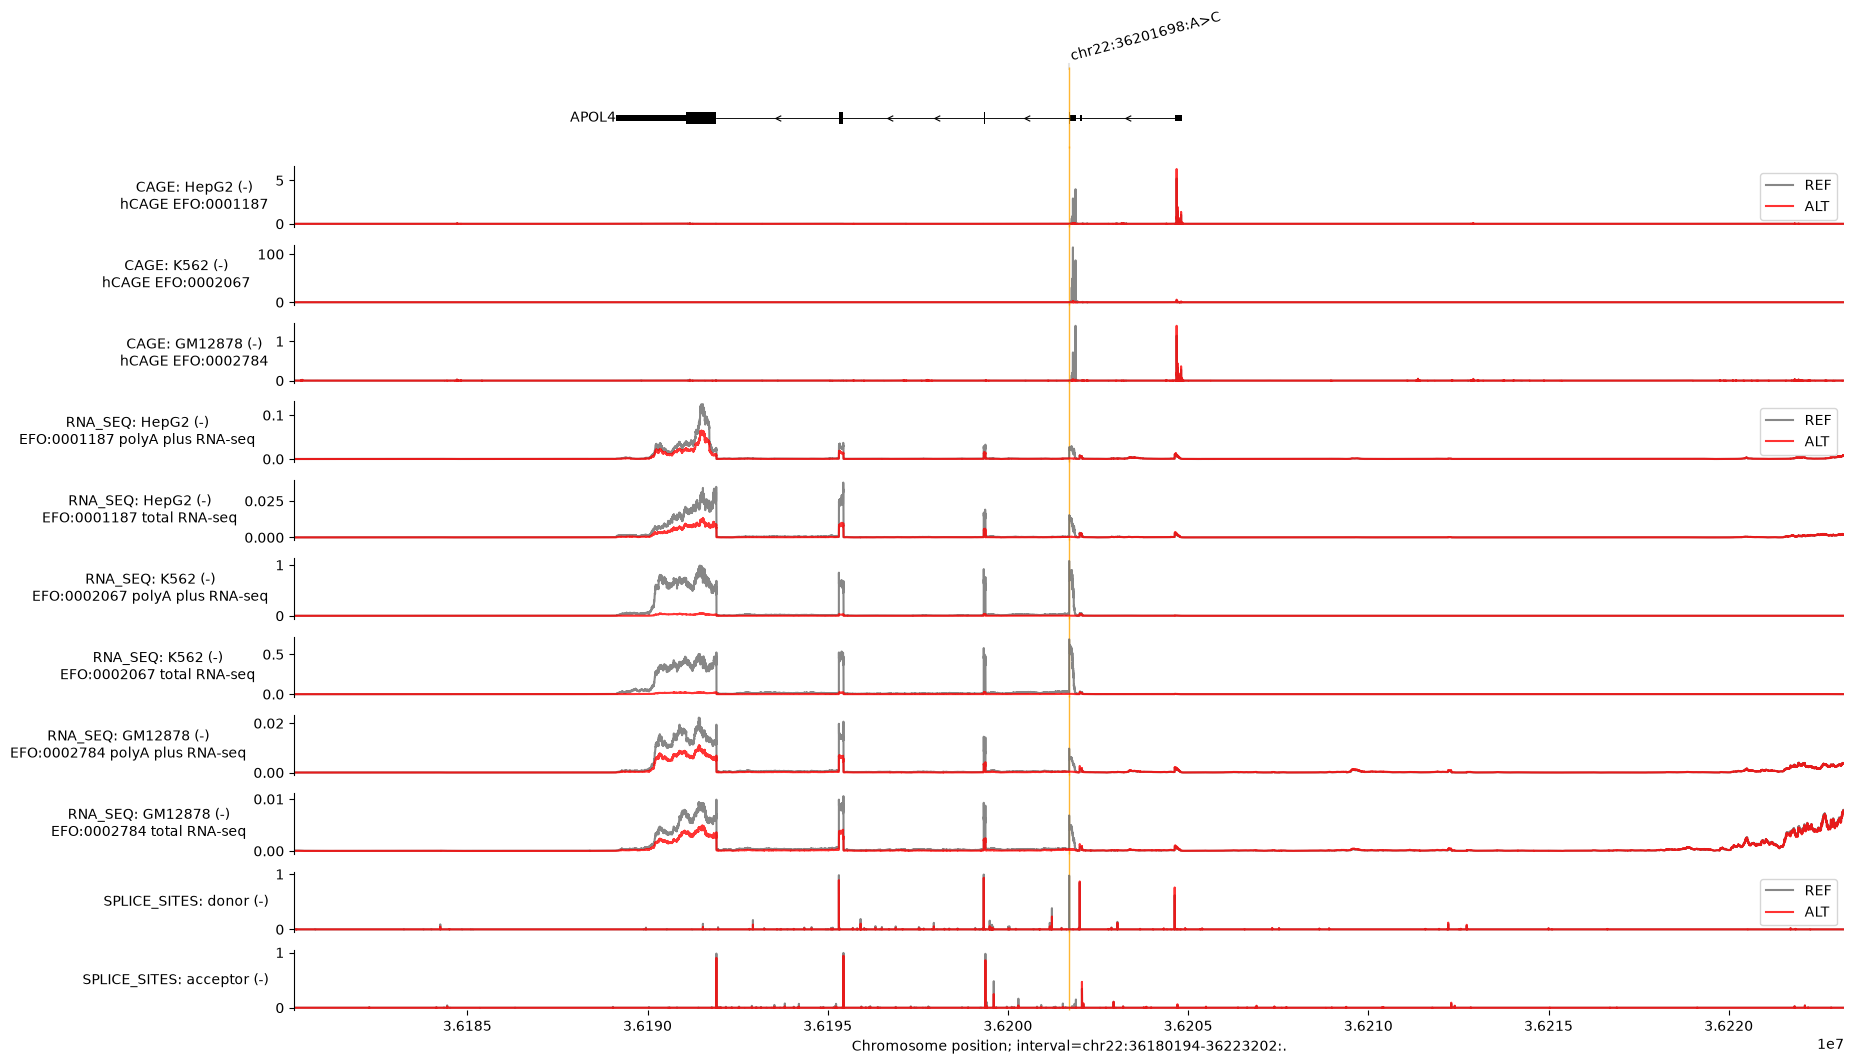

In [7]:
# @title Visualize variant effects { run: "auto" }
# @markdown We can also visualise the predicted effects of the variant by first predicting tracks for the REF and ALT alleles:

# @markdown Specify list of cell and tissue ontologies:
ontology_terms = ['EFO:0001187', 'EFO:0002067', 'EFO:0002784']  # @param

# @markdown Gene and transcript annotation options:
plot_gene_annotation = True  # @param { type: "boolean" }
plot_longest_transcript_only = True  # @param { type: "boolean" }

# @markdown Output types to plot (if present in output):
plot_rna_seq = True  # @param { type: "boolean" }
plot_cage = True  # @param { type: "boolean" }
plot_atac = False  # @param { type: "boolean" }
plot_dnase = False  # @param { type: "boolean" }
plot_chip_histone = False  # @param { type: "boolean" }
plot_chip_tf = False  # @param { type: "boolean" }
plot_splice_sites = True  # @param { type: "boolean" }
plot_splice_site_usage = False  # @param { type: "boolean" }
plot_contact_maps = False  # @param { type: "boolean" }
plot_splice_junctions = False  # @param { type: "boolean" }

# @markdown Option to filter tracks to only a specific DNA strand:
filter_to_positive_strand = False  # @param { type: "boolean" }
filter_to_negative_strand = True  # @param { type: "boolean" }
if filter_to_positive_strand and filter_to_negative_strand:
  raise ValueError(
      'Cannot specify both filter_to_positive_strand and '
      'filter_to_negative_strand.'
  )

# @markdown Specify a list of Transription Factors to select from CHIP_TF outputs e.g. ['IKZF1'].
# These must be contained in the 'transcription_factor' column of the CHIP_TF metadata.
transcription_factors = None  # @param

# @markdown Other visualization options:
ref_color = 'dimgrey'  # @param { type: "string" }
alt_color = 'red'  # @param { type: "string" }
ref_alt_colors = {'REF': ref_color, 'ALT': alt_color}
plot_interval_width = 43008 # @param { type: "slider", min: 2048, max: 1048576, step: 2048}
plot_interval_shift = 0 # @param { type: "slider", min: -524288, max: 524288, step: 2048}


# Load gene annotation.
if organism in _transcript_extractor_cache:
  transcript_extractor, longest_transcript_extractor = (
      _transcript_extractor_cache[organism]
  )
else:
  match organism:
    case dna_client.Organism.HOMO_SAPIENS:
      gtf_path = HG38_GTF_FEATHER
    case dna_client.Organism.MUS_MUSCULUS:
      gtf_path = MM10_GTF_FEATHER
    case _:
      raise ValueError(f'Unsupported organism: {organism}')

  gtf = pd.read_feather(gtf_path)

  # Filter to protein-coding genes and highly supported transcripts.
  gtf_transcript = gene_annotation.filter_transcript_support_level(
      gene_annotation.filter_protein_coding(gtf), ['1']
  )

  # Extractor for identifying transcripts in a region.
  transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

  # Also define an extractor that fetches only the longest transcript per gene.
  gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
      gtf_transcript
  )
  longest_transcript_extractor = transcript.TranscriptExtractor(
      gtf_longest_transcript
  )
  _transcript_extractor_cache[organism] = (
      transcript_extractor,
      longest_transcript_extractor,
  )


def _predict_variant_cached(
    interval, variant, organism, requested_outputs, ontology_terms
):
  """Cache wrapper of dna_model.predict_variant."""
  # Create a unique key from the function arguments.
  cache_key = (
      str(interval),
      str(variant),
      str(organism),
      tuple(requested_outputs),
      tuple(ontology_terms),
  )

  # Check if the result is already in the cache.
  if cache_key in _prediction_cache:
    return _prediction_cache[cache_key]

  # If not, compute the prediction and store it in the cache.
  result = dna_model.predict_variant(
      interval=interval,
      variant=variant,
      organism=organism,
      requested_outputs=requested_outputs,
      ontology_terms=ontology_terms,
  )
  _prediction_cache[cache_key] = result
  return result


output = _predict_variant_cached(
    interval=interval,
    variant=variant,
    organism=organism,
    requested_outputs=[*dna_client.OutputType],
    ontology_terms=ontology_terms,
)

# Filter to DNA strand if requested.
ref, alt = output.reference, output.alternate

if filter_to_positive_strand:
  ref = ref.filter_to_strand(strand='+')
  alt = alt.filter_to_strand(strand='+')
elif filter_to_negative_strand:
  ref = ref.filter_to_strand(strand='-')
  alt = alt.filter_to_strand(strand='-')

# Function to filter to TFs if requested.


def _maybe_filter_to_tfs(
    tdata: track_data.TrackData,
) -> track_data.TrackData | None:
  if not plot_chip_tf:
    return tdata

  if plot_chip_tf and (transcription_factors is not None):
    if not isinstance(transcription_factors, list):
      raise ValueError('TFs must be input as a list of strings.')
    if not isinstance(transcription_factors[0], str):
      raise ValueError('TFs must be input as a list of strings.')

  if transcription_factors is None:
    return tdata

  tf_rows = tdata.metadata.index[
      tdata.metadata['transcription_factor'].isin(transcription_factors)
  ]
  if not tf_rows.any():
    print(
        f'No tracks found for specified transcription factors and'
        f' ontology_terms.'
    )
    return None
  missing_tfs = set(transcription_factors).difference(
      set(tdata.metadata['transcription_factor'])
  )
  if missing_tfs:
    print(
        f'Could not find tracks in chip_tf outputs corresponding to the'
        f' following requested TFs'
    )
  return tdata.select_tracks_by_index(tf_rows)


# Build plot.
components = []

# Gene and transcript annotation.
if plot_gene_annotation:
  if plot_longest_transcript_only:
    transcripts = longest_transcript_extractor.extract(interval)
  else:
    transcripts = transcript_extractor.extract(interval)
  components.append(plot_components.TranscriptAnnotation(transcripts))


# Individual output type plots.
plot_map = {
    'plot_atac': (ref.atac, alt.atac, 'ATAC'),
    'plot_cage': (ref.cage, alt.cage, 'CAGE'),
    'plot_chip_histone': (ref.chip_histone, alt.chip_histone, 'CHIP_HISTONE'),
    'plot_chip_tf': (
        _maybe_filter_to_tfs(ref.chip_tf),
        _maybe_filter_to_tfs(alt.chip_tf),
        'CHIP_TF',
    ),
    'plot_contact_maps': (ref.contact_maps, alt.contact_maps, 'CONTACT_MAPS'),
    'plot_dnase': (ref.dnase, alt.dnase, 'DNASE'),
    'plot_rna_seq': (ref.rna_seq, alt.rna_seq, 'RNA_SEQ'),
    'plot_splice_junctions': (
        ref.splice_junctions,
        alt.splice_junctions,
        'SPLICE_JUNCTIONS',
    ),
    'plot_splice_sites': (ref.splice_sites, alt.splice_sites, 'SPLICE_SITES'),
    'plot_splice_site_usage': (
        ref.splice_site_usage,
        alt.splice_site_usage,
        'SPLICE_SITE_USAGE',
    ),
}

for key, (ref_data, alt_data, output_type) in plot_map.items():
  if eval(key) and ref_data is not None and ref_data.values.shape[-1] == 0:
    print(
        f'Requested plot for output {output_type} but no tracks exist in'
        ' output. This is likely because this output does not exist for your'
        ' ontologies or requested DNA strand.'
    )
  if eval(key) and ref_data and alt_data:
    match output_type:
      case 'CHIP_HISTONE':
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{histone_mark}}'
        )
      case 'CHIP_TF':
        ylabel_template = (
            f'{output_type}: {{biosample_name}}'
            ' ({strand})\n{transcription_factor}'
        )
      case 'CONTACT_MAPS':
        ylabel_template = f'{output_type}: {{biosample_name}} ({{strand}})'
      case 'SPLICE_SITES':
        ylabel_template = f'{output_type}: {{name}} ({{strand}})'
      case _:
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{name}}'
        )

    if output_type == 'CONTACT_MAPS':
      component = plot_components.ContactMapsDiff(
          tdata=alt_data - ref_data,
          ylabel_template=ylabel_template,
      )
      components.append(component)
    elif output_type == 'SPLICE_JUNCTIONS':
      ref_plot = plot_components.Sashimi(
          ref_data,
          ylabel_template='REF: ' + ylabel_template,
      )
      alt_plot = plot_components.Sashimi(
          alt_data,
          ylabel_template='ALT: ' + ylabel_template,
      )
      components.extend([ref_plot, alt_plot])
    else:
      component = plot_components.OverlaidTracks(
          tdata={'REF': ref_data, 'ALT': alt_data},
          colors=ref_alt_colors,
          ylabel_template=ylabel_template,
      )
      components.append(component)

if plot_interval_width > interval.width:
  raise ValueError(
      f'plot_interval_width ({plot_interval_width}) must be less than '
      f'interval.width ({interval.width}).'
  )

plot = plot_components.plot(
    components=components,
    interval=interval.shift(plot_interval_shift).resize(plot_interval_width),
    annotations=[
        plot_components.VariantAnnotation([variant]),
    ],
)